# 02 · Parameters

`client.predict(model, photo)` works with no options. But the options (we also call them
**parameters**) change the answer a lot. In this notebook you change one parameter at a time and
compare the pictures **before** and **after**.

**What you will learn**

- `box_threshold` and `text_threshold`: how sure a box must be
- how the **words** of a prompt change the answer
- `min_size` and `max_size`: drop objects that are too small or too large
- `roi`: look at one part of the photo only
- `dilate`: make masks larger or smaller
- point labels: "on the object" and "not on the object"
- `resize`, `jpeg_quality`: what the client sends
- a **slider** that runs the model again when you move it

**Time needed:** about 40 minutes.

**What you need before you start**

- notebooks [00](00-overview-and-quickstart.ipynb) and [01](01-tour-of-tasks.ipynb)
- a running server; models `grounding-dino`, `rf-detr`, `grounded-sam`, `mobile-sam`
  (downloaded the first time)

**Steps**

1. `box_threshold` and `text_threshold`
2. The words of the prompt
3. `min_size` and `max_size`
4. `roi`: region of interest
5. `dilate`: grow or shrink masks
6. Point labels: on and off the object
7. Client resize and JPEG quality
8. A slider for `box_threshold`

An option that you do not give is **not sent**. Then the server uses the model's own default
value. An option that a model does not use is ignored (no error). The table of
[every option](https://mtbui2010.github.io/visionserve/clients/python/#every-option-at-a-glance) says which model reads which option.

## Setup

In [1]:
from PIL import Image
from handson import connect, ensure_model, photo, show, show_side_by_side, mark, draw, table

client = connect()
for name in ["grounding-dino", "rf-detr", "grounded-sam", "mobile-sam"]:
    ensure_model(client, name)

Connected to VisionServe at http://127.0.0.1:11435: {'status': 'ok'}
Model 'grounding-dino' is installed (state: loaded).
Model 'rf-detr' is installed (state: loaded).
Model 'grounded-sam' is installed (state: loaded).
Model 'mobile-sam' is installed (state: loaded).


**What you see**

One line for the connection and one line per model.

<details><summary><b>In detail</b></summary>

If a model is missing, `ensure_model` downloads it (once). In Docker, set `VISIONSERVE_CLI`
first (see the README).

</details>

## 1. `box_threshold` and `text_threshold`

`grounding-dino` looks at about 900 possible boxes and gives each one a **score** for each
word of your prompt. A
**threshold** is a minimum value: a box is kept only if its score is above the threshold.

- `box_threshold` (default 0.3): **lower** finds more objects, but also more mistakes.
  **Higher** keeps only the boxes the model is sure about.
- `text_threshold` (default 0.25): a second minimum on the same score. It only changes the
  answer when you set it **above** `box_threshold`.

box_threshold=None: [('cat', 0.9), ('laptop', 0.88), ('couch', 0.33), ('couch', 0.41), ('remote control', 0.31)]
box_threshold=0.35: [('cat', 0.9), ('laptop', 0.88), ('couch', 0.41)]


box_threshold=0.5: [('cat', 0.9), ('laptop', 0.88)]
text_threshold=0.4: [('cat', 0.9), ('laptop', 0.88), ('couch', 0.41)]


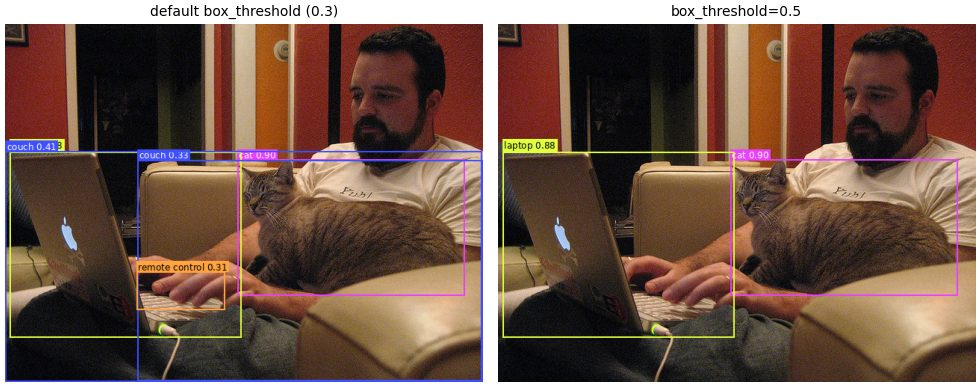

In [2]:
words = "cat. laptop. couch. remote control."
results = {}
for bt in [None, 0.35, 0.5]:                    # None = the model's default (0.3)
    results[bt] = client.predict("grounding-dino", photo("cat"), prompt=words, box_threshold=bt)
    print(f"box_threshold={bt}:", [(d.cls, round(d.conf, 2)) for d in results[bt].detections])

res_tt = client.predict("grounding-dino", photo("cat"), prompt=words, text_threshold=0.4)
print("text_threshold=0.4:", [(d.cls, round(d.conf, 2)) for d in res_tt.detections])

show_side_by_side([(photo("cat"), results[None]), (photo("cat"), results[0.5])],
                  titles=["default box_threshold (0.3)", "box_threshold=0.5"])

**What you see**

- With the default (0.3) there are 5 boxes: cat, laptop, two "couch" boxes and a "remote
  control" with a low score (about 0.31).
- At 0.35 the weak couch box and the remote control are gone. At 0.5 only the cat and the
  laptop stay.
- `text_threshold=0.4` gives the same answer as `box_threshold=0.4` would: both are minimums
  on the same score.

<details><summary><b>In detail</b></summary>

- How to choose: start with the default. If you see wrong boxes, raise `box_threshold`. If you
  miss objects, lower it (but not much below 0.2).
- Closed-set detectors such as `rf-detr` ignore these two options. Their minimum is fixed in the
  model's manifest. Filter their answer with `res.filter_by_conf(0.8)`.
- Read more: [`box_threshold`](https://mtbui2010.github.io/visionserve/clients/python/#box_threshold) and [`text_threshold`](https://mtbui2010.github.io/visionserve/clients/python/#text_threshold).

</details>

## 2. The words of the prompt

The prompt is not only "what to find". The **exact words** matter. A more precise word often
gives a higher score, and a general word can match more things than you want.

We try three pairs of prompts: a short word and a more precise one.

photo,prompt,boxes,scores
desk,screen.,2,"0.40, 0.40"
desk,monitor.,1,0.68
desk,phone.,1,0.42
desk,mobile phone.,1,0.60
food,pepper.,1,0.58
food,orange pepper.,1,0.75


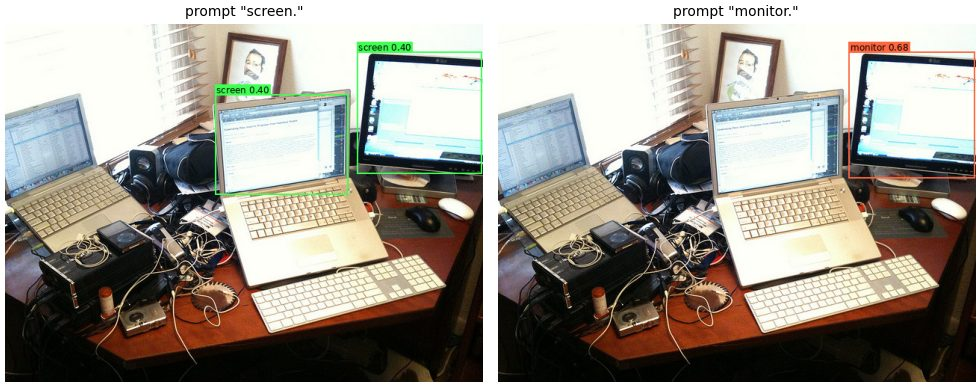

In [3]:
pairs = [("desk", "screen."), ("desk", "monitor."),
         ("desk", "phone."), ("desk", "mobile phone."),
         ("food", "pepper."), ("food", "orange pepper.")]
rows, answers = [], {}
for key, prompt in pairs:
    res = client.predict("grounding-dino", photo(key), prompt=prompt)
    answers[prompt] = res
    rows.append([key, prompt, len(res.detections), ", ".join(f"{d.conf:.2f}" for d in res.detections)])
table(rows, ["photo", "prompt", "boxes", "scores"])

show_side_by_side([(photo("desk"), answers["screen."]), (photo("desk"), answers["monitor."])],
                  titles=['prompt "screen."', 'prompt "monitor."'])

**What you see**

- "screen." finds **two** boxes: the monitor and the screen of a laptop. "monitor." finds only
  the monitor, with a higher score.
- "mobile phone." scores higher than "phone.", and "orange pepper." higher than "pepper.".
- So: use the words that a person would write in a photo caption.

<details><summary><b>In detail</b></summary>

- GroundingDINO learned from photos with captions. Words that often appear in captions work
  best: "mobile phone", not "smartphone device".
- A color or a material can help: "red mug", "wooden chair". A very long description does not
  help much.
- Upper and lower case do not matter. Separate several objects with dots:
  `"monitor. mobile phone. mouse."`. Read more: [`prompt`](https://mtbui2010.github.io/visionserve/clients/python/#prompt-text).

</details>

## 3. `min_size` and `max_size`

These two options drop objects by **size**. The size is the area of the box (`w x h`) in
**percent of the photo's area**.

- `min_size=1`: keep only objects that cover at least 1 % of the photo (drop small ones).
- `max_size=1`: keep only objects that cover at most 1 % of the photo (drop large ones).

They work with every model that returns boxes or masks.

{} [('person', 4.09), ('dog', 1.95), ('dog', 0.97), ('person', 3.45), ('dog', 1.22), ('dog', 1.42), ('bench', 3.94)]
{'min_size': 1} [('person', 4.09), ('dog', 1.95), ('person', 3.45), ('dog', 1.22), ('dog', 1.42), ('bench', 3.94)]
{'max_size': 1} [('dog', 0.97)]


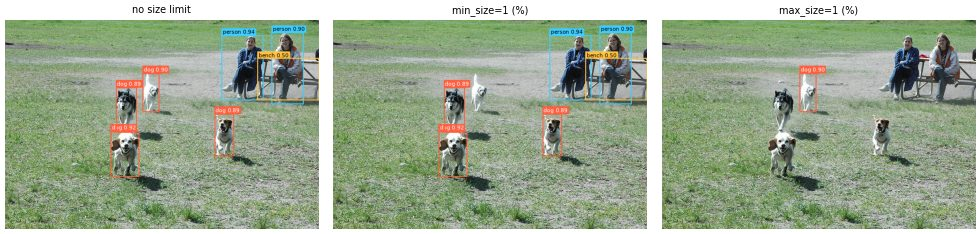

In [4]:
w, h = Image.open(photo("dogs")).size
sizes = {}
for kw in [{}, {"min_size": 1}, {"max_size": 1}]:
    res = client.predict("rf-detr", photo("dogs"), **kw)
    sizes[str(kw)] = res
    print(kw, [(d.cls, round(100 * d.bbox[2] * d.bbox[3] / (w * h), 2)) for d in res.detections])

show_side_by_side([(photo("dogs"), sizes["{}"]), (photo("dogs"), sizes["{'min_size': 1}"]),
                   (photo("dogs"), sizes["{'max_size': 1}"])],
                  titles=["no size limit", "min_size=1 (%)", "max_size=1 (%)"])

**What you see**

The second number of each pair is the box's share of the photo in percent.

- Without a limit there are 7 objects.
- With `min_size=1` the smallest dog (0.97 %) is gone.
- With `max_size=1` only that small dog stays.

<details><summary><b>In detail</b></summary>

- Use `min_size` to remove tiny false detections far away. Use `max_size` to remove a "whole
  photo" box (for example a table that fills the view).
- The server applies the filter after the model, so it does not make the model faster.
- On your side, `res.filter_by_size(...)` does the same, but with **fractions** (0 to 1), not
  percent. Read more: [`min_size` and `max_size`](https://mtbui2010.github.io/visionserve/clients/python/#min_size-and-max_size).

</details>

## 4. `roi`: region of interest

`roi=[x, y, w, h]` tells the server: *cut out this rectangle and run the model on this part
only*. The answer is still in the pixels of the **whole** photo.

Use it when only one part of the camera view matters, for example a conveyor belt or a table.

dog 0.94 [226, 139, 42, 90]
dog 0.93 [281, 109, 34, 79]
dog 0.92 [216, 228, 58, 92]
dog 0.91 [428, 193, 32, 87]


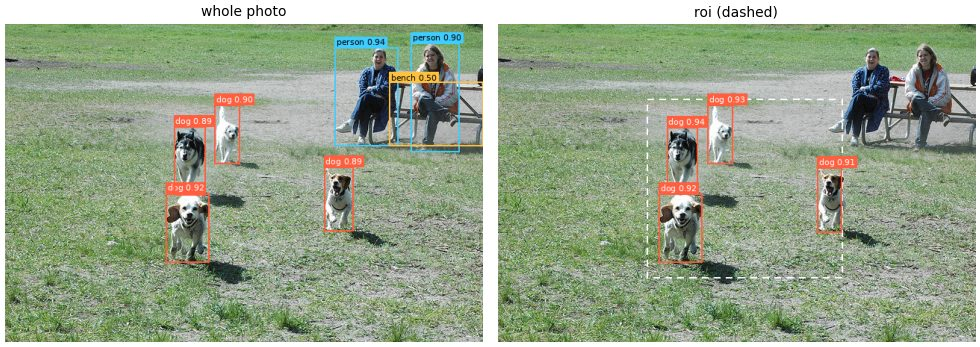

In [5]:
roi = [200, 100, 260, 240]                     # x, y, w, h in the photo's pixels
full = client.predict("rf-detr", photo("dogs"))
part = client.predict("rf-detr", photo("dogs"), roi=roi)
for d in part.detections:
    print(d.cls, round(d.conf, 2), [round(v) for v in d.bbox])

show_side_by_side([(photo("dogs"), full), (mark(photo("dogs"), boxes=roi), part)],
                  titles=["whole photo", "roi (dashed)"])

**What you see**

- Right: only the 4 dogs inside the dashed rectangle are found. The people and the bench are
  outside, so the model never sees them.
- The dog on the right edge of the rectangle is cut; the model finds the visible part.
- The boxes are in whole-photo pixels (compare them with the left picture).
- The scores change a little: the model sees a smaller picture, so each dog is larger for it.

<details><summary><b>In detail</b></summary>

- If `w` and `h` are both 1 or less, the four numbers are **fractions** of the photo:
  `roi=[0.25, 0.25, 0.5, 0.5]` is the center of any photo, whatever its size.
- `roi` works with every model. A depth map or an embedding computed with `roi` describes only
  the cut-out part. Read more: [`roi`](https://mtbui2010.github.io/visionserve/clients/python/#roi-region-of-interest).

</details>

## 5. `dilate`: grow or shrink masks

`dilate` changes every mask by a number of **pixels**:

- `dilate=5`: grow each mask by 5 pixels on every side (a safety margin, for example to blur
  an object completely, or for a robot that must not touch it).
- `dilate=-3`: shrink each mask by 3 pixels (stay safely inside the object, for example to
  measure its color).

We zoom in on one dog to see the difference.

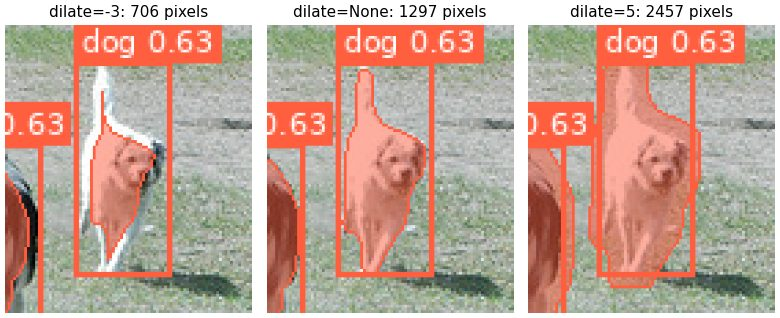

In [6]:
w, h = Image.open(photo("dogs")).size
zoom = (255, 95, 345, 200)                     # left, top, right, bottom of the zoom area
crops, titles = [], []
for dl in [-3, None, 5]:
    res = client.predict("grounded-sam", photo("dogs"), prompt="dog.", dilate=dl)
    i = min(range(len(res.masks)), key=lambda k: abs(res.masks[k].bbox[0] - 281))  # the dog at x=281
    pixels = int(res.masks[i].to_ndarray(w, h).sum())
    crops.append(draw(photo("dogs"), res).crop(zoom).resize((270, 315), Image.NEAREST))
    titles.append(f"dilate={dl}: {pixels} pixels")
show_side_by_side(crops, titles=titles, max_width=800)

**What you see**

Three zoomed pictures of the same dog. The colored area is the mask:

- `dilate=-3`: the mask is thinner and stays inside the dog.
- `dilate=None` (off): the mask as the model made it.
- `dilate=5`: the mask is wider and covers the edge of the dog and a little grass.

The pixel count in each title grows from left to right.

<details><summary><b>In detail</b></summary>

- `dilate` changes only masks, not detection boxes. With `grounded-sam`, each mask keeps the box
  of its detection, so the pairs (detection, mask) stay correct.
- It uses a square shape, so corners grow a bit more than straight edges.
- Read more: [`dilate`](https://mtbui2010.github.io/visionserve/clients/python/#dilate).

</details>

## 6. Point labels: on and off the object

A point prompt for `mobile-sam` can have a **label**: `[x, y, 1]` means *this pixel is on the
object* (green dot), `[x, y, 0]` means *this pixel is NOT on the object* (red cross).
All points together describe **one** object.

In notebook 01, one point on an elephant gave a mask of two elephants. Now we add a "not this"
point on the second elephant.

one point            mask bbox=[335, 147, 218, 171]  pixels=23701
with a 'not' point   mask bbox=[406, 147, 147, 171]  pixels=17427


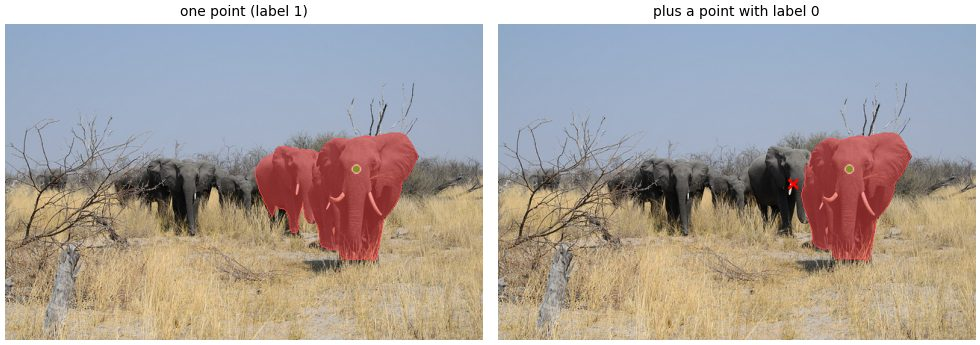

In [7]:
w, h = Image.open(photo("elephant")).size
one = [470, 195]                                # on the front elephant
two = [[470, 195, 1], [395, 215, 0]]            # ... and NOT the elephant behind it
res_one = client.predict("mobile-sam", photo("elephant"), point=one)
res_two = client.predict("mobile-sam", photo("elephant"), point=two)
for name, res in [("one point", res_one), ("with a 'not' point", res_two)]:
    m = res.masks[0]
    print(f"{name:20s} mask bbox={[round(v) for v in m.bbox]}  pixels={int(m.to_ndarray(w, h).sum())}")

show_side_by_side([(mark(photo("elephant"), points=one), res_one),
                   (mark(photo("elephant"), points=two), res_two)],
                  titles=["one point (label 1)", "plus a point with label 0"])

**What you see**

- Left: one green dot; the mask covers two elephants.
- Right: the red cross on the second elephant removes it. The mask is now one elephant: its box
  starts more to the right and it has fewer pixels.

<details><summary><b>In detail</b></summary>

- A point without a label counts as label 1.
- A box prompt is often easier than points when objects touch. You can also give **several
  boxes** to get one mask per box.
- Read more: [`point`](https://mtbui2010.github.io/visionserve/clients/python/#point-points) and [`box`](https://mtbui2010.github.io/visionserve/clients/python/#box-boxes).

</details>

## 7. Client resize and JPEG quality

Before it sends a photo, the Python client can make it **smaller** (*client resize*, see
notebook 00). Three options control this, per call or for the whole `Client`:

- `resize="auto"` (default): shrink only photos that are larger than the model can use.
  `resize="off"`: always send the photo as it is. `resize=320`: make the longest side 320 pixels.
- `jpeg_quality` (default 90): the quality of the JPEG file that is sent after a shrink. Lower
  means a smaller file but more **compression artifacts** (blocks and blur).

First a large photo (a 6 times larger copy of the dogs photo), then a very low JPEG quality.

large photo: 3840 x 2556 pixels, 2720 kB


resize='auto' sent: ClientResize(original_width=3840, original_height=2556, sent_width=1683, sent_height=1120, jpeg_quality=90, reason='hint')
               6 objects, total time 292 ms


resize='off'  sent: None
               6 objects, total time 386 ms
quality 90: [('person', 0.91), ('dog', 0.89), ('dog', 0.89), ('person', 0.89), ('dog', 0.89), ('dog', 0.88)]
quality 10: [('person', 0.86), ('person', 0.71), ('dog', 0.66), ('dog', 0.56)]


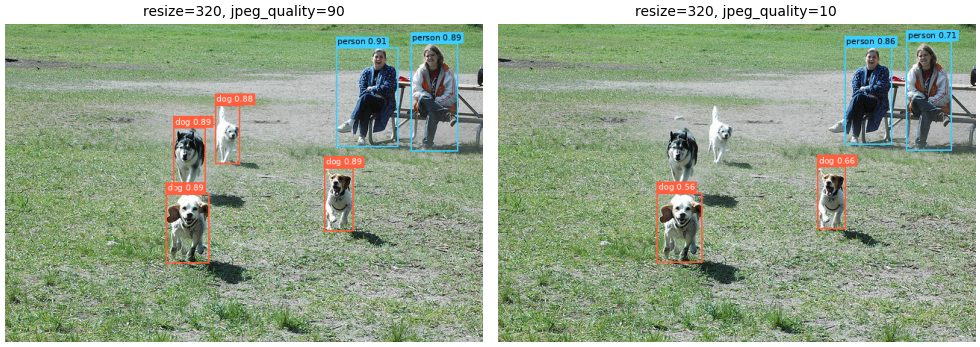

In [8]:
import io, time

buf = io.BytesIO()
Image.open(photo("dogs")).resize((3840, 2556)).save(buf, "JPEG", quality=95)
big = buf.getvalue()                            # the bytes of a large JPEG, like a camera gives
print(f"large photo: 3840 x 2556 pixels, {len(big) // 1000} kB")
for opt in ["auto", "off"]:
    t0 = time.perf_counter()
    res = client.predict("rf-detr", big, resize=opt)
    ms = 1000 * (time.perf_counter() - t0)
    print(f"resize={opt!r:6s} sent: {res.client_resize}")
    print(f"               {len(res.detections)} objects, total time {ms:.0f} ms")

q90 = client.predict("rf-detr", photo("dogs"), resize=320)
q10 = client.predict("rf-detr", photo("dogs"), resize=320, jpeg_quality=10)
print("quality 90:", [(d.cls, round(d.conf, 2)) for d in q90.detections])
print("quality 10:", [(d.cls, round(d.conf, 2)) for d in q10.detections])
show_side_by_side([(photo("dogs"), q90), (photo("dogs"), q10)],
                  titles=["resize=320, jpeg_quality=90", "resize=320, jpeg_quality=10"])

**What you see**

- With `"auto"` the client sent a smaller photo (see `sent_width` and `sent_height`), and it
  found the same objects as with `"off"` (`None` means: sent as it is). On one computer the
  two times are close, because sending is free here. Over a network, the smaller upload makes
  `"auto"` much faster.
- At 320 pixels and quality 90, all dogs and people are still found. At quality 10 the photo is
  so damaged that some dogs are lost and the scores drop.

<details><summary><b>In detail</b></summary>

- In short: keep the defaults. Use `resize="off"` when you compare results pixel by pixel.
  Lower `jpeg_quality` only on a slow network, and check the results.
- Models that return masks (and OCR, grasps) always get the full photo in `"auto"` mode,
  because they need every pixel.
- Read more: [Client-side resizing](https://mtbui2010.github.io/visionserve/clients/python/#client-side-resizing-on-by-default) and
  [What it costs and saves](https://mtbui2010.github.io/visionserve/clients/python/#what-it-costs-and-saves).

</details>

## 8. A slider for `box_threshold`

**ipywidgets** adds controls such as sliders to a notebook. Here, when you move the slider,
the notebook sends the request again with the new `box_threshold` and draws the new answer.

**Note:** a slider needs a **running** notebook (a live Python kernel). If you read this
notebook on GitHub, you see no slider, only the saved picture for the start value (0.30). Run
the cell in Jupyter to use it.

FloatSlider(value=0.3, continuous_update=False, description='box_threshold', max=0.8, min=0.1, step=0.05, styl…

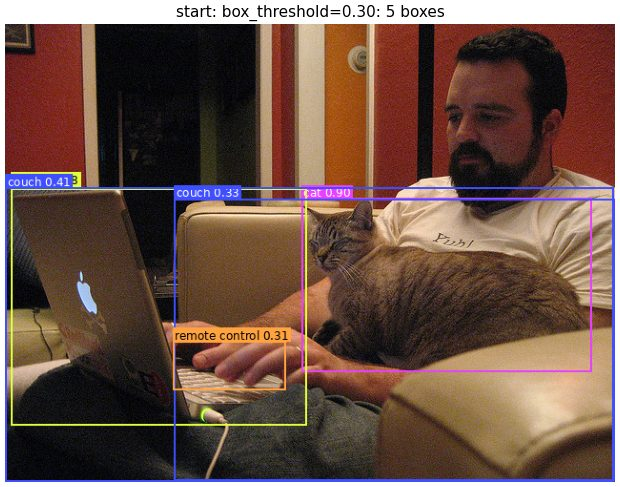

Output()

In [9]:
import ipywidgets as widgets
from IPython.display import display

prompt = "cat. laptop. couch. remote control."
slider = widgets.FloatSlider(value=0.30, min=0.10, max=0.80, step=0.05, description="box_threshold",
                             continuous_update=False, style={"description_width": "initial"})
new_pictures = widgets.Output()                 # pictures for new slider values go here

def redraw(change):
    with new_pictures:
        new_pictures.clear_output(wait=True)
        res = client.predict("grounding-dino", photo("cat"), prompt=prompt, box_threshold=slider.value)
        show(photo("cat"), res, title=f"box_threshold={slider.value:.2f}: {len(res.detections)} boxes",
             max_width=640)

slider.observe(redraw, names="value")
display(slider)

# The picture for the start value (0.30). It is a normal output, so it is saved in the notebook.
start = client.predict("grounding-dino", photo("cat"), prompt=prompt, box_threshold=slider.value)
show(photo("cat"), start, title=f"start: box_threshold={slider.value:.2f}: {len(start.detections)} boxes",
     max_width=640)
display(new_pictures)

**What you see**

A slider and the cat photo with the boxes for the start value, `box_threshold=0.30`. When you
move the slider, a **new** picture appears **below** the first one. Move it to the right: boxes
disappear, the weakest first. Move it to the left (0.10 to 0.20): more boxes appear, and many of
them are wrong.

<details><summary><b>In detail</b></summary>

- `continuous_update=False` sends a request only when you release the slider, not for every
  small move.
- `slider.observe(redraw, names="value")` means: call `redraw` each time the value changes.
  `widgets.Output()` is an area that `redraw` can clear and fill again.
- The same pattern works for any option: `min_size`, `dilate`, `roi`... Make one slider per
  option and read all values in `redraw`. For a quick version, see `widgets.interact` in the
  [ipywidgets documentation](https://ipywidgets.readthedocs.io/).
- If you see no slider in Jupyter Lab, install `ipywidgets` in the same environment as Jupyter
  and reload the page.

</details>

## Recap

| Option | Read by | What it does |
|---|---|---|
| `box_threshold`, `text_threshold` | GroundingDINO models | minimum score to keep a box |
| `prompt` words | open-vocabulary models | precise caption words score higher |
| `min_size`, `max_size` | every model with boxes or masks | drop objects by area, in % of the photo |
| `roi` | every model | run on a part of the photo; answer in whole-photo pixels |
| `dilate` | every model with masks | grow (+) or shrink (-) masks, in pixels |
| point label 1 / 0 | SAM models | "on the object" / "not on the object" |
| `resize`, `jpeg_quality` | the Python client | what is uploaded; results stay in your photo's pixels |

Change one option at a time and look at the picture: this is the fastest way to tune.

## Next

- **[03 · What a model takes and gives back](03-inspect-a-model.ipynb)**: what goes into a model and what comes out.
- **[08 · Robotics](08-robotics.ipynb)**: depth, grasps and the support surface.
- Every option, with more examples: [Python client](https://mtbui2010.github.io/visionserve/clients/python/).